# Hands-on Introduction to Bioimage Classification with Convolutional Neural Networks

SPAOM 2026<br>
6-9 Oct 2026<br>
Jose Requejo-Isidro (CNB, CSIC), Carlo Manzo (UVic-UCC)

*This community workshop is part of the activities of AIM-Net (RED2024-153844-T, funded by MICIU/AEI/10.13039/501100011033).*

## Summary
This notebook provides you with a complete code example that loads the malaria dataset, compares a dense and a convolutional neural network (NN)  to classify the images of cells with and without malaria.

We will investigate the effect of the training set size, batch size, and how to inspect where the trained network fails, understanding metrics and showing the network activations and heatmaps.

The code is amply based on Code Example 3-A from the book:

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>


The dataset we will use was originally published in S. Rajaraman, et al, _Pre-trained convolutional neural networks as feature extractors toward improved malaria parasite detection in thin blood smear images._ PeerJ 6, e4568, 2018.

### CPU/GPU configuration

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [ ]:
# !pip install deeplay  # Uncomment if using Colab/Kaggle.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>If running locally:</strong> <br>
<strong>- CPU only:</strong> Ignore this notice. <br>
<strong>- GPU enabled:</strong> You need to uncomment the code in the cell below this one.
</div>

In [ ]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"]="0" # Uncomment if using your own GPU. Modify the GPU ID accordingly.

## Loading the dataset
Loads the images into a folder containing one subdirectory per class.

We will use `ImageFolder` to load the images and classes. `ImageFolder` is a PyTorch class that automatically loads the images into a folder that contains one subdirectory per class.
It  organizes images by class (the classes attribute).

In [1]:
import os
from torchvision.datasets.utils import _extract_zip, download_url
dataset_path= os.path.join('.', 'blood_smears_dataset')
if not os.path.exists(dataset_path):
    url='https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip'
    download_url (url,'.')
    _extract_zip ('cell_images.zip', dataset_path, None)
    os.remove('cell_images.zip')

100%|██████████| 353M/353M [00:05<00:00, 61.0MB/s] 


In [65]:
from torchvision.datasets import ImageFolder

base_dir = os.path.join (dataset_path, 'cell_images')
full_dataset = ImageFolder(base_dir)

`full_dataset` contains the images and their labels.
It is illustrative to inspect the properties of `full_dataset`. The first index corresponds to the image, the second to its label.

dataset data type <class 'torchvision.datasets.folder.ImageFolder'>
Images data type: <class 'PIL.Image.Image'>
Labels data type class: <class 'int'>
Number of images in the dataset: 27558
Image size: (151, 139)
Image size: (160, 145)
Image size: (121, 118)


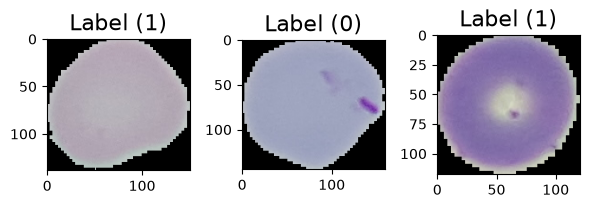

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
print ("dataset data type", type(full_dataset))
print ("Images data type:", type(full_dataset[0][0]))
print ("Labels data type class:", type(full_dataset[0][1]))
print ("Number of images in the dataset:", len(full_dataset))

fig, axs = plt.subplots(1, 3, figsize=(6, 3))
for ax in axs.ravel():
    #Pick 3 images randomly from the dataset and display them
    image, label = full_dataset [np.random.randint(0, len (full_dataset))]
    print ("Image size:", image.size)
    ax.imshow(image)
    ax.set_title (f'Label ({label})', fontsize=16)
plt.tight_layout()
plt.show()



## Working with tensors
Loaded images are numpy arrays and have different sizes. However, NNs process multi-dimensional data that cannot fit into vectors or 2D matrices. 

We define a transformation to resize all images to 28 by 28 pixels and convert them to PyTorch tensors (`ToTensor()` also normalizes their values between 0 and 1)

In [9]:
from torchvision.transforms import Compose, Resize, ToTensor

#Compose permite encadenar transformaciones, en ese caso Resize y ToTensor (convierte la imagen a un tensor y la reescala de 0 a 1)
image_trans = Compose([Resize((28, 28)), ToTensor()])

`ImageFolder` assigns labels alphabetically. In this case, labels are defined in an unconventional way (0 is parasitised).

In [10]:
import torch

def label_trans(label):
    #Convierte label en un tensor y cada valor de label en un float. Le añade una dimensión para después
    return torch.tensor(1-label).float().unsqueeze(-1)

We can now reload the dataset. `full_dataset`is now a tensor

In [11]:
full_dataset = ImageFolder (base_dir, transform=image_trans, target_transform=label_trans)

One of the parameters we always wonder about its importance is the size of the dataset we use for training. <br>
The following function allows to choose class-balanced datasets of different sizes. 

You may use this later to investigate the effect of the training set size in the learning process. 

In [12]:
from collections import defaultdict

def get_balanced_subset(dataset, num_per_class=50):
    # num_per_class is the number of images per class
    # 1. Group all original indices by their class label
    class_indices = defaultdict(list)
    
    # If using ImageFolder, dataset.targets maps index to class ID
    for idx, target in enumerate(dataset.targets):
        class_indices[target].append(idx)
        
    # 2. Select a fixed number of indices from each class
    selected_indices = []
    for target, indices in class_indices.items():
        if len(indices) < num_per_class:
            raise ValueError(f"Class {target} only has {len(indices)} samples, but you requested {num_per_class}.")
        # Randomly choose indices for this class
        chosen = np.random.choice(indices, num_per_class, replace=False)
        selected_indices.extend(chosen)
        
    # 3. Create the PyTorch Subset
    subset = torch.utils.data.Subset(dataset, selected_indices)
    
    # 4. Attach required properties to the subset so it behaves like the original
    subset.classes = dataset.classes
    subset.targets = [dataset.targets[i] for i in selected_indices]
    
    # Attach .samples (paths and labels) if available (e.g., ImageFolder)
    if hasattr(dataset, 'samples'):
        subset.samples = [dataset.samples[i] for i in selected_indices]
        
    return subset

We will start with 6000 images per class

In [13]:
# Get num_per_class images per category
dataset = get_balanced_subset(full_dataset, num_per_class=6000)

# If you prefer to use the full data set:
# dataset = full_dataset
print(f"Total images in set: {len(full_dataset)}")
print(f"Total images in subset: {len(dataset)}")

Total images in set: 27558
Total images in subset: 12000


## Visualising the images

In [14]:
def plot_blood_smears (dataset):
    fig, axs = plt.subplots(3, 6, figsize=(16, 8))
    for ax in axs.ravel():
        image, label = dataset [np.random.randint(0, len (dataset))]
        # Now image is a torch tensor
        if isinstance(image, torch.Tensor):
            image, label = image.numpy().transpose(1,2,0), label.numpy()
        ax.imshow (image)
        ax.set_title (f'Parasitized ({label})' if label == 1 else f'Uninfected ({label})', fontsize=16)
    plt.tight_layout()
    plt.show()

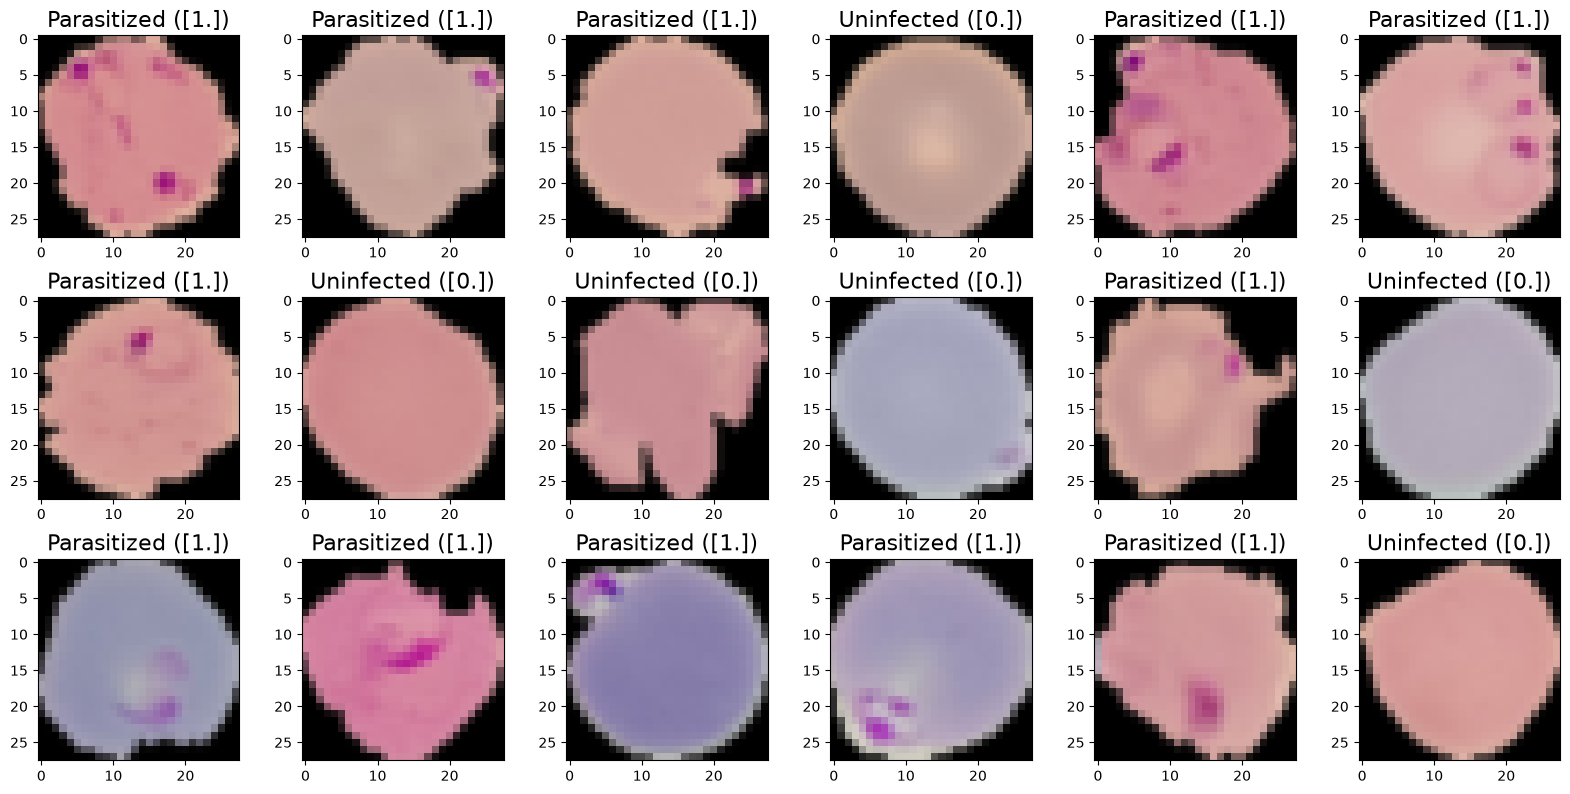

In [15]:
plot_blood_smears(dataset)

## Train, validation, and test sets

A common practice is to split the dataset into training and test sets using an 80/20 ratio. <br>
When a validation set is included, a common split is 80% training, 10% validation, and 10% test, or something similar.

The validation set is used to diagnose learning issues such as overfitting, among others.

In [16]:
g=torch.Generator().manual_seed(42)
train, val, test = torch.utils.data.random_split(dataset, [0.7, 0.15, 0.15], generator=g)

### Loaders and batches

Next, data loaders (iterable objects) are created.

The training dataset is usually shuffled so that batches are randomly and more uniformly distributed. This is not necessary  for the validation and the test datasets.

A batch allows the model to average over many samples when updating the weights, which reduces noise (stabilizing training) and improves computational efficiency, although they take up more RAM space. The training set batch's size is a hyperparameter that can be changed.

For the test set, batches are used solely to speed up evaluation by improving computational efficiency.

You may examine the effect of batch size on training: increasing the training batch size is often equivalent to reducing the learning rate in the learning curve (MSE vs. epochs).

In [17]:
#Dataloader is a wrapper that makes the dataset iterable
train_loader = torch.utils.data.DataLoader(train, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val, batch_size=128, shuffle=False)
test_loader = torch.utils.data.DataLoader(test, batch_size=256, shuffle=False)

## Classifying with a DNN
One of our goals is to understand the difference between a DNN and a CNN. We will start with a DNN.

A binary classifier returns a continuous score between 0 and 1, which is converted into a binary classification (0 or 1) using an arbitrary threshold.

The most appropriate threshold is selected based on performance metrics such as the AUROC, precision-recall (PR) curve, $F_1$ or related metrics.

`Deeplay` is a PyTorch extension that allows the architecture of NNs to be modified after they have been created.

We generate the model with the architecture of a dense  NN. 
It has one input per pixel and channel (total number of input features is H × W × C), two hidden layers (128 neurons) with ReLU activation functions and a final layer that combines all the activations and uses a sigmoidal  function to convert the score into a probability.

In [18]:
import deeplay as dl

dnn=dl.MultiLayerPerceptron(in_features=28*28*3, hidden_features=[128, 128], out_features=1, out_activation=torch.nn.Sigmoid)

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


We can print the detailed architecture

In [19]:
print (dnn)

MultiLayerPerceptron(
  (blocks): LayerList(
    (0): LinearBlock(
      (layer): Layer[Linear](in_features=2352, out_features=128, bias=True)
      (activation): Layer[ReLU]()
    )
    (1): LinearBlock(
      (layer): Layer[Linear](in_features=128, out_features=128, bias=True)
      (activation): Layer[ReLU]()
    )
    (2): LinearBlock(
      (layer): Layer[Linear](in_features=128, out_features=1, bias=True)
      (activation): Layer[Sigmoid]()
    )
  )
)


We compile the structure.

`dl.BinaryClassifier` is a ready-made application in Deeplay. It defines the neural network architecture and training process, including the loss, and optimizer. <br>
The loss function (BCE) measures the difference between the model's prediction and the ground-truth label. <br>
The optimizer updates weights and adapt the learning rates during training. 

In [20]:
dnn_classifier=dl.BinaryClassifier (model=dnn, optimizer=dl.RMSprop(lr=0.001)).create()

...and print out its detailed structure

In [ ]:
#print(dnn_classifier)

### Training the Dense Neural Network

NNs are trained with the train dataset. The validation dataset is used to fine-tune the training hyperparameters.

We will start with a trainer with 5 epochs. <br>
The number of epochs is a hyperparameter that can be changed to tune the NN. You may investigate later its effect on the learning process. 

In [21]:
dnn_trainer = dl.Trainer (max_epochs=5, accelerator="auto")
dnn_trainer.fit(dnn_classifier, train_dataloaders=train_loader, val_dataloaders=val_loader)

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss              │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │     0 │
│ 4 │ model         │ MultiLayerPerceptron │  317 K │ train │     0 │
│ 5 │ optimizer     │ RMSprop              │      0 │ train │     0 │
└───┴───────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 317 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 317 K                                                                                                
Total estimated model params size (MB): 1.271                                                                      
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 4: 100%|██████████| 263/263 [00:04<00:00, 56.09it/s, v_num=0, train_loss_step=0.621, trainBinaryAccuracy_step=0.500, val_loss_step=0.687, valBinaryAccuracy_step=0.625, val_loss_epoch=0.649, valBinaryAccuracy_epoch=0.619, train_loss_epoch=0.616, trainBinaryAccuracy_epoch=0.660]


### Measuring performance: Testing the DNN

Testing must be performed on a dataset that has not been used during training, that is, neither the training nor the validation sets.

The first performance metric is its accuracy. Accuracy is  the fraction of correctly classified images:

$\text{Accuracy} = \frac{TP + TN}{\text{Total}}$

where TP (True Positives) and TN (True Negatives) are the numbers of correctly classified positive and negative samples, respectively. <br> 
Chance accuracy equals 0.5

In [22]:
dnn_trainer.test (dnn_classifier, test_loader)

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 8/8 [00:00<00:00,  8.54it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testBinaryAccuracy_epoch  │    0.6155555844306946     │
│      test_loss_epoch      │    0.6500966548919678     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.6500966548919678,
  'testBinaryAccuracy_epoch': 0.6155555844306946}]

## Classifying with a CNN 
A CNN takes into account the spatial arrangement of features in an image.

We are going to improve the classification using a CNN with a final dense layer (dense top).

**Why a dense layer?** Convolutional layers extract spatial features (edges, textures, patterns), which are local relationships in space. Dense layers combine these spatial features into global representations.

`dl.ConvolutionalNeuralNetwork` initializes a ready-made CNN base in Deeplay.<br>
The CNN will have 3 input channels (the colour channels), and 3 hidden layers with 16, 16, and 32 filters (feature maps).<br>
The output layer has 32 convolutional filters that will be sent to a dense top.<br>
Each of this layers use a ReLU activation function.

In [23]:
conv_base = dl.ConvolutionalNeuralNetwork(in_channels=3, hidden_channels=[16, 16, 32], out_channels=32)

Maxpooling between the second and third hidden layers to reduce the number of parameters while retaining the strongest activations (highest pixel values in the feature maps). 

In [24]:
conv_base.blocks[2].pool.configure(torch.nn.MaxPool2d, kernel_size=2)

CNN-DNN connection: Averages the 2D features map to connect the CNN and the dense top. <br>
Adaptive Average Pooling computes the average value of each feature map, thus reducing every feature map to a single number:<br>
32 14x14 feature maps -> 32 (convolutional) features.

In [25]:
connector = dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=1)

Finally the dense top, that uses a sigmoidal activation function to convert scores into probabilities 

In [26]:
dense_top=dl.MultiLayerPerceptron(in_features=32, hidden_features=[], out_features=1, out_activation=torch.nn.Sigmoid)

And we combine the CNN base, connector and dense top into a cnn 

In [27]:
cnn=dl.Sequential(conv_base, connector, dense_top)
print (cnn)

Sequential(
  (0): ConvolutionalNeuralNetwork(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (1): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (2): Conv2dBlock(
        (pool): Layer[MaxPool2d](kernel_size=2)
        (layer): Layer[Conv2d](in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (3): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        (activation): Layer[Identity]()
      )
    )
  )
  (1): Layer[AdaptiveAvgPool2d](output_size=1)
  (2): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Layer[Linear](in_features=32, out_features=1, bias=Tr

We compile the CNN:

In [28]:
cnn_classifier = dl.BinaryClassifier (model=cnn, optimizer=dl.RMSprop(lr=0.001)).create()

In [ ]:
#print (cnn_classifier)

### Training the Convolutional Neural Network

As above, the number of epochs is a hyperparameter that can be tuned.

In [29]:
cnn_trainer=dl.Trainer(max_epochs=5, accelerator="auto")
cnn_trainer.fit(cnn_classifier, train_dataloaders=train_loader, val_dataloaders=val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │ 16.7 K │ train │     0 │
│ 5 │ optimizer     │ RMSprop          │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 16.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.7 K                                                                                               
Total estimated model params size (MB): 0.067                                                                      
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 4: 100%|██████████| 263/263 [00:05<00:00, 48.57it/s, v_num=1, train_loss_step=0.561, trainBinaryAccuracy_step=0.750, val_loss_step=0.708, valBinaryAccuracy_step=0.625, val_loss_epoch=0.539, valBinaryAccuracy_epoch=0.731, train_loss_epoch=0.603, trainBinaryAccuracy_epoch=0.682]


Testing the CNN:

In [30]:
cnn_trainer.test(cnn_classifier, test_loader)

Testing DataLoader 0: 100%|██████████| 8/8 [00:01<00:00,  7.90it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testBinaryAccuracy_epoch  │    0.7450000047683716     │
│      test_loss_epoch      │    0.5365651845932007     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.5365651845932007,
  'testBinaryAccuracy_epoch': 0.7450000047683716}]

## Learning curves

Learning curves let you peek into the learning process and choose the optimal number of training epochs to prevent underfitting and overfitting. <br>
We will see how learning has proceeded in every **validation** step (after every epoch is completed):
1. If training loss doesn't decrease something is wrong

2. Underfitting and overfitting:
    - **Underfitting:** both train and validation loss stay high and close together.
    - **Overfitting:** Train keeps improving while validation stalls or gets worse.
    - **Good fit:** both curves decrease and converge to similar values with a small gap.

Deeplay trainer logs the training history that can be retrieved to check the learning process:

In [31]:
train_history = cnn_trainer.history.history
#print(h.keys())  # see the exact names, e.g. train_loss_epoch, val_loss_epoch, ...

### Training / Validation loss and accuracy curves

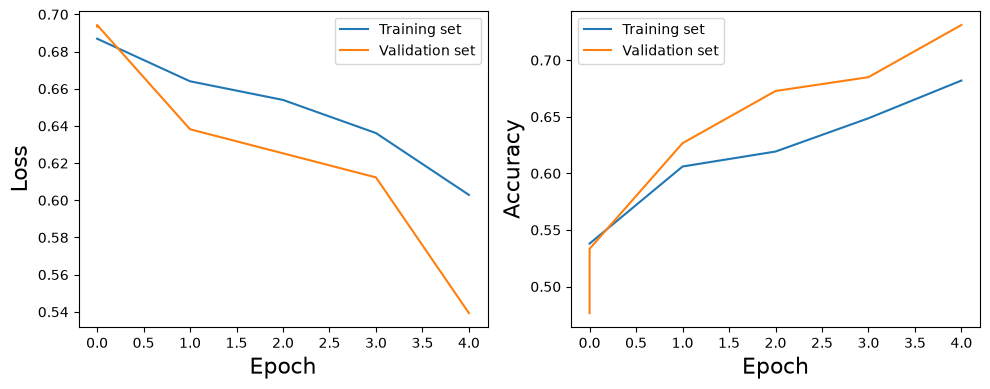

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=[10, 4])

# Loss
ax[0].plot(train_history["train_loss_epoch"]["epoch"], train_history["train_loss_epoch"]["value"], label="Training set")
ax[0].plot(train_history["val_loss_epoch"]["epoch"], train_history["val_loss_epoch"]["value"], label="Validation set")
ax[0].set_xlabel("Epoch", fontsize=16); ax[0].set_ylabel("Loss",fontsize=16)
ax[0].legend()

# Accuracy
ax[1].plot(train_history["trainBinaryAccuracy_epoch"]["epoch"], train_history["trainBinaryAccuracy_epoch"]["value"], label="Training set")
ax[1].plot(train_history["valBinaryAccuracy_epoch"]["epoch"], train_history["valBinaryAccuracy_epoch"]["value"], label="Validation set")
ax[1].set_xlabel("Epoch", fontsize=16); ax[1].set_ylabel("Accuracy", fontsize=16)
ax[1].legend()

plt.tight_layout()
plt.show()


# Measuring the performance

Recall that testing must be performed on a dataset that has not been used during training, that is, neither the training set nor the validation set.


## The ROC curve and AUC ROC

The ROC (Receiver Operating Characteristic) curve  tells you how well the model performs at every possible decision threshold. <br>
It is the relationship between true positive rates and false positive rates for each threshold value:

$\text{TPR} = \frac{TP}{TP + FN}$;  $\text{FPR} = \frac{FP}{FP + TN}$

Perfect ROC curve: TPR=1 for FPR=0

The metric related to the ROC curve is the *area under the ROC curve* (AUC ROC). <br>
An AUC of 0.5 corresponds to a random classifier.




In [34]:
import torchmetrics as tm

def plot_roc(classifier, loader):
    roc=tm.ROC(task="binary")
    for image, label in loader:
        roc.update(classifier(image), label.long())

    fig, ax = roc.plot (score=True)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Baseline (AUC = 0.5)")
    ax.grid(False)
    ax.axis("square")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="best")
    plt.show()

We may now compare the ROC curve and AUC ROC of the cnn classifier against the dnn classifier:

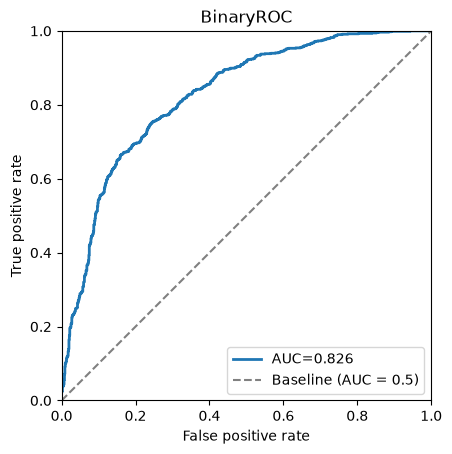

In [35]:
plot_roc (cnn_classifier, test_loader)

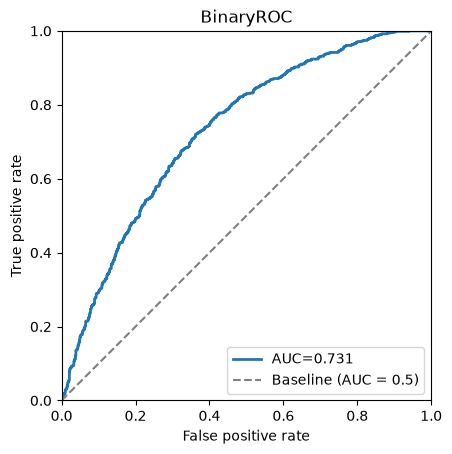

In [36]:
plot_roc (dnn_classifier, test_loader)

The ROC curve becomes deceptive when the majority class overwhelms the data. In such a case (overly imbalanced data) it is better to use the PR curve.

## Precision-recall (PR) curve

The PR curve shows the trade-off between precision (fraction of TP among all samples predicted as positive (TP+FP)) and recall (fraction of TP among all actual positive samples (TP+FN)).<br>

$\text{Precision}=\frac{TP}{TP+FP}$; $\text{Recall}=\frac{TP}{TP+FN}$; 

Perfect classifier: precision =1, recall =1. AUC-PR=1 <br>
Random classifier: AUC-PR=prevalence (fraction of TP among all samples).

**Why is there a trade-off between precision and recall?**<br>
Given the probability of a sample belonging to one class or another, a decision has to be made whether to assign the sample to one class or the other:<br>
Changing the decision threshold affects the numbers of FP and FN. Lowering the threshold increases the number of predicted positives, which in turn results in fewer FN (increased recall), but more FP (decreased precision).

Remember: TP: true positives, FP: false positives; TN: true negatives; FN: false negatives.

In [ ]:
def plot_prcurve(classifier, loader):

    pr_curve = tm.PrecisionRecallCurve(task="binary")
    #precision, recall, thresholds = pr_curve(pred, target)
    for image, label in loader:
        pr_curve.update(classifier(image), label.long())

    #Fraction of ground truth positives
    label_test = np.concatenate([label.cpu().numpy() for _, label in test_loader])
    prevalence = label_test.mean()          # binary case, labels in {0, 1}

    fig, ax = pr_curve.plot (score=True)
    ax.axhline(prevalence, color="gray", linestyle="--", label=f"Baseline (prevalence = {prevalence:.3f})")
    ax.grid(False)
    ax.axis("square")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="best")
    plt.show()

    # p, r, thr = pr_curve.compute()

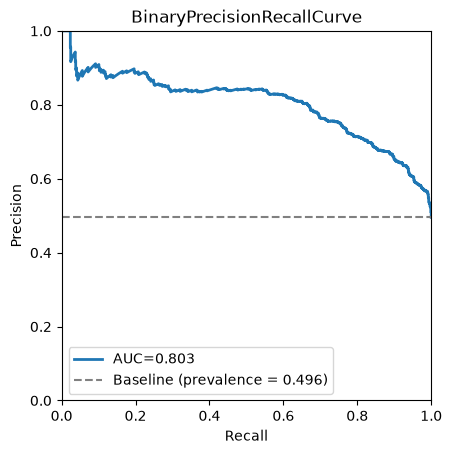

In [38]:
plot_prcurve (cnn_classifier, test_loader)

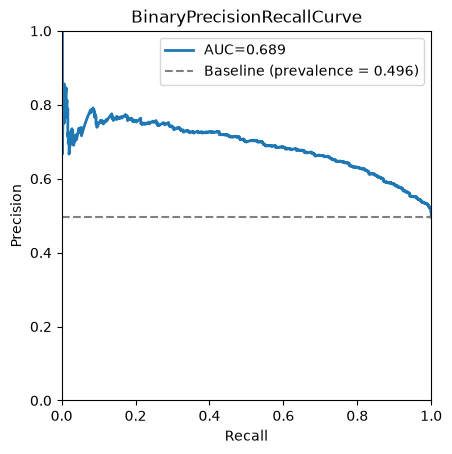

In [39]:
plot_prcurve (dnn_classifier, test_loader)

# Classifying!
The model outputs a probability. Given the probability, we make a decision based on a decision threshold, turning the probability into a classification label. 

## Choosing a classification threshold. The $F_1$ score

The $F_1$ score measures the balance between precision and recall. It is most useful when both FP and FN are relevant.

$F_1=\frac{2⋅Precision \times Recall}{Precision + Recall​}$

$F_1$ is high only when both precision and recall are high. It penalizes extreme values. 

The optimal decision threshold maximises the $F_1$ metric for the validation set.

In [40]:
def f1_curve(classifier, loader):
    outputs = cnn_trainer.predict(classifier, loader)
    scores = torch.cat(outputs).squeeze(-1)
    labels = torch.cat([label for _, label in loader])
    labels=labels.squeeze(-1).long() 
    cnn_pr_curve = tm.PrecisionRecallCurve(task="binary")
    p, r, thr = cnn_pr_curve(scores, labels) 

    f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
    best = f1.argmax()
    best_f1 = f1[best].item()
    best_thr = thr[best].item()
    return f1, best_f1, best_thr

We estimate the scores for the validation dataset

In [41]:
f1_val, best_f1_val, best_thr=f1_curve(cnn_classifier, val_loader)
print(f"Best threshold = {best_thr:.3f}, F1 = {best_f1_val:.3f}")

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 15/15 [00:01<00:00, 13.43it/s]
Best threshold = 0.307, F1 = 0.764


The corresponding F1 for the model (using unseen data) is thus:

In [42]:
# f1_model_test, best_f1_test, _ =f1_curve(cnn_classifier, test_loader)
# print(f"F1 score for the model = {best_f1_test:.3f}")

# Scores on the test set
outputs = cnn_trainer.predict(cnn_classifier, test_loader)
test_scores = torch.cat(outputs).squeeze(-1)
test_labels = torch.cat([label for _, label in test_loader]).squeeze(-1).long()

# F1 on unseen data, using the threshold chosen on the validation set
f1_metric = tm.F1Score(task="binary", threshold=best_thr)
f1_test = f1_metric(test_scores, test_labels).item()
print(f"Test F1 at the validation threshold ({best_thr:.3f}) = {f1_test:.3f}")

Predicting DataLoader 0: 100%|██████████| 8/8 [00:00<00:00, 15.55it/s] 
Test F1 at the validation threshold (0.307) = 0.764


Let's see if it works on unseen images!

Let's choose a clearly infected one for the purposes of illustration from the test set


Text(0.5, 1.0, '[1.]')

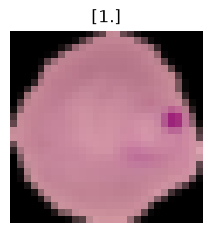

In [46]:
# from PIL import Image
# labels = np.array(dataset.targets)[test.indices]
# # Label transform and target_transform are applied when a sample is retrieved, not in the original dataset
# labels = (1 - labels).astype(np.float32)
# im_ind = np.random.choice(np.where(labels ==1)[0])
# image_filename= dataset.samples[im_ind][0]
# image_hr = Image.open(image_filename) #image hr is a np array with order HxWxC
# image, label = dataset[im_ind][0], dataset[im_ind][1] #Here labels are transfromed
# img, label = image.numpy().transpose(1,2,0), label.numpy()
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[2.5,2.5])
# ax.imshow(img, cmap="gray")
# ax.axis("off")
# ax.set_title (label)

from PIL import Image

# Labels of the test samples, in the order of test.indices
test_labels = np.array(dataset.targets)[test.indices]
# ImageFolder labels: 0 = parasitized, so apply the same flip as label_trans
test_labels = (1 - test_labels).astype(np.float32)

# Pick a random parasitized test sample, then map its position back to an index in `dataset`
pos = np.random.choice(np.where(test_labels == 1)[0])
im_ind = test.indices[pos]

image_filename = dataset.samples[im_ind][0]
image_hr = Image.open(image_filename)          # PIL image, full resolution

image, label = dataset[im_ind]                 # transformed: 28x28 tensor, flipped label
img, label = image.numpy().transpose(1, 2, 0), label.numpy()

fig, ax = plt.subplots(figsize=[2.5, 2.5])
ax.imshow(img)
ax.axis("off")
ax.set_title(label)

... and now the predicted classification

In [47]:
pred = cnn_classifier.model(image.unsqueeze(0)) 
pred_prob=pred.detach().item()
pred_label = int(pred_prob >= best_thr)
print ('The predicted class is ', end='')
print (f'Parasitized ({pred_label})' if pred_label == 1 else f'Uninfected ({pred_label})')
print ('Ground truth is ', end='')
print (f'Parasitized ({label})' if label == 1 else f'Uninfected ({label})')

The predicted class is Parasitized (1)
Ground truth is Parasitized ([1.])


# How is the model learning?
Filters, activations and Grad-CAM.

Deeplay terminology:
- model: high-level neural network architecture container (computation unit).
- blocks a small container in a specific model that typically contains layers (conv2d), activation, pooling operations...
- weight is a kernel tensor corresponding to a specific layer with dimensions (out_channels, in_channels, kH, kW)

You can check the hierarchy printing the CNN:
In our CNN: `model[0]` contains the main convolutional structure, `model[1]` contains the connector and `model[2]` is the fully connected dense classifier at the end.

The following code navigates through the model's first module (`model[0]`), selects the first convolutional layer (`blocks[0]`), and then targets the layer's filters of the 16th feature (`layer.weight[15]`).

In [48]:
filter = cnn_classifier.model[0].blocks[0].layer.weight[15]
print (filter.size())
print (filter)

torch.Size([3, 3, 3])
tensor([[[ 0.0080, -0.0315,  0.2290],
         [ 0.0204,  0.0398,  0.2074],
         [ 0.0757, -0.0315,  0.0242]],

        [[-0.1209, -0.1595, -0.1279],
         [-0.1149, -0.1107, -0.0161],
         [-0.1122,  0.1420, -0.2256]],

        [[-0.0652,  0.0966,  0.1102],
         [-0.0170, -0.0186, -0.0987],
         [-0.1313,  0.1067,  0.0674]]], grad_fn=<SelectBackward0>)


## Hooks: a window into the model's mind

A hook is a function that gets called at specific moments during weight updating (training) letting you intercept and inspect the output without changing the model's code.

## Visualising activations

_Activations_ are the output values of neurons after applying the activation function. In a CNN, activations are feature maps whose pixel intensities represent the neuron outputs at different spatial locations.

We will use the previous (infected) image from the test set.

We define a function to visualize the activations:

In [ ]:
def plot_activations (activations, cols=8):
    """Visualise activations"""
    rows = -(activations.shape[0] // -cols) #ceiling division

    fig, axs = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    for i, ax in enumerate (axs.ravel()):
        ax.axis("off")
        if i < activations.shape[0]:
            ax.imshow (activations[i].numpy())
            ax.set_title(i, fontsize=16)
    plt.show()

We access the activations and call `plot_activations` from the hook:

In [50]:
def hook_func(layer, input, output):
    '''Hook for activations'''
    activations = output.detach().clone()
    print (f"Activations size: {activations.size()}")
    plot_activations(activations[0])

We now _hook_ our function to the forward pass in the four convolutional layers (blocks) of our CNN.<br>

Do not forget to remove the hook! Otherwise it will always execute in the forward pass!

Activations size: torch.Size([1, 16, 28, 28])


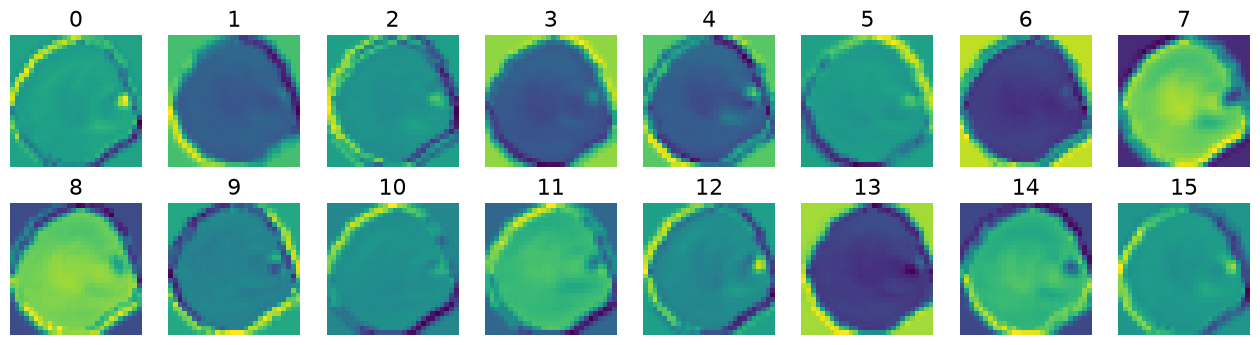

Activations size: torch.Size([1, 16, 28, 28])


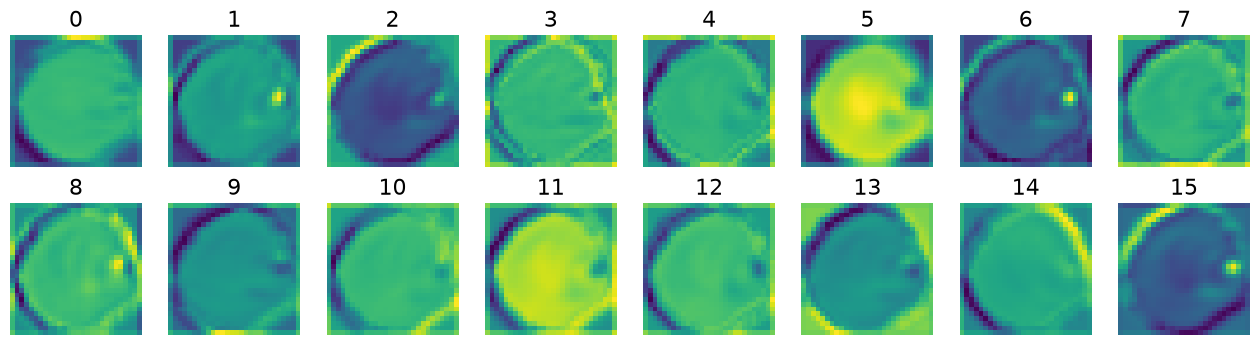

Activations size: torch.Size([1, 32, 14, 14])


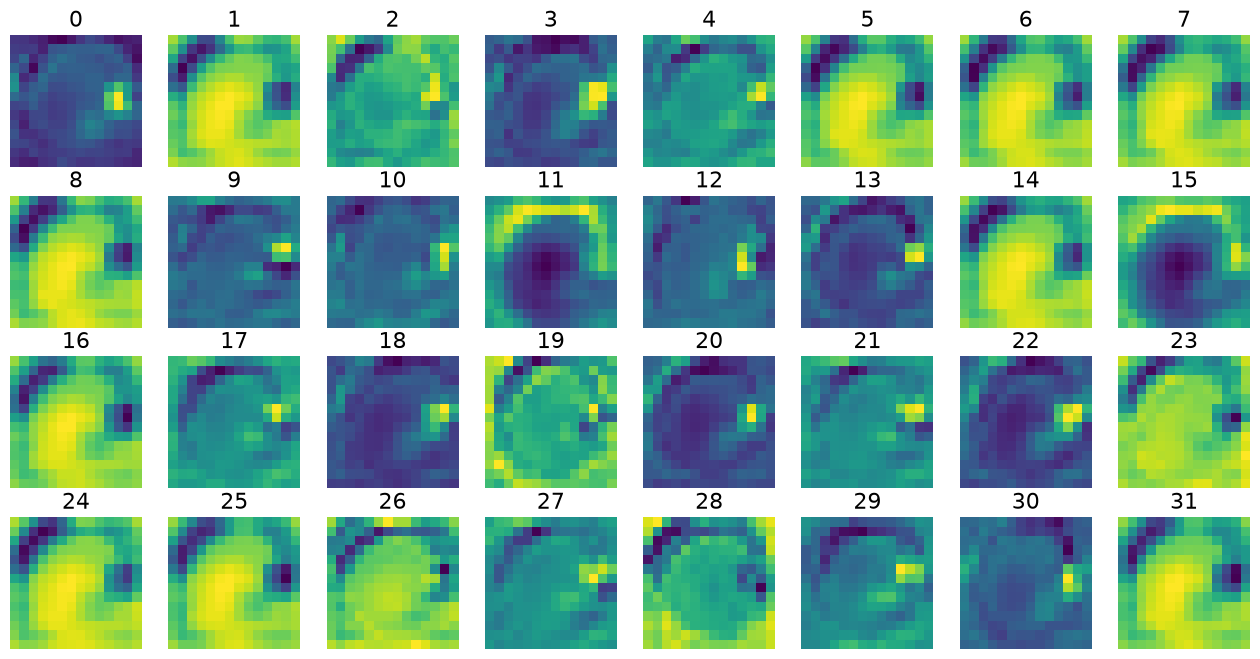

Activations size: torch.Size([1, 32, 14, 14])


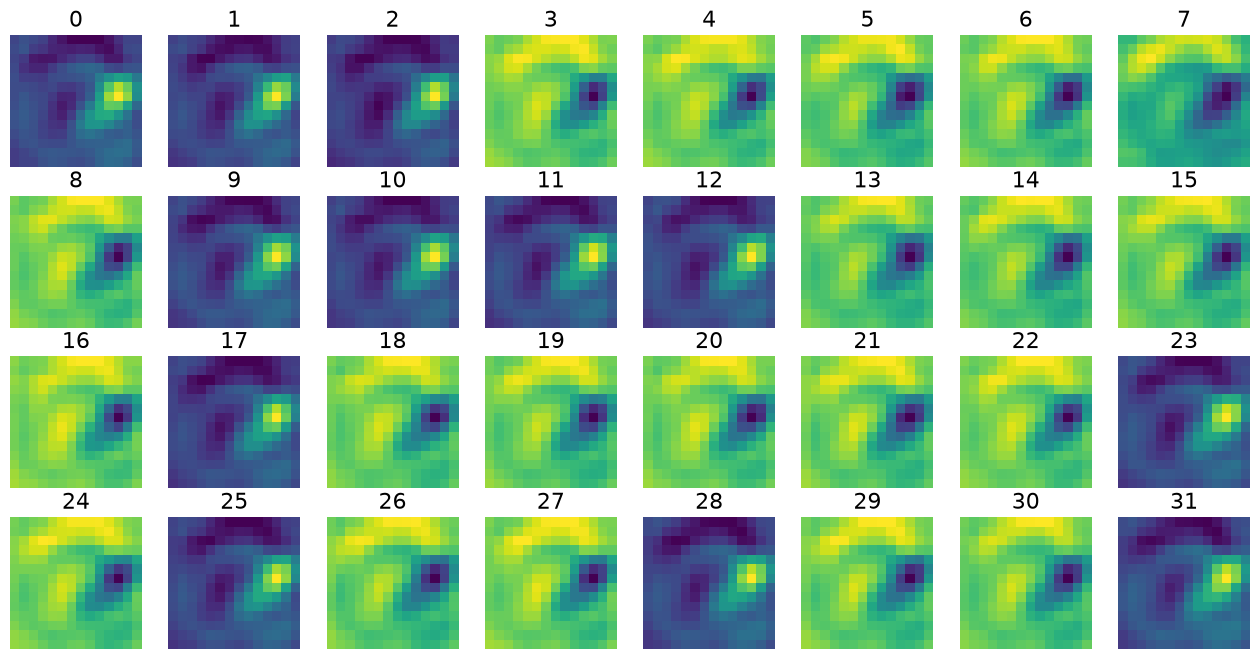

In [51]:
for block in cnn_classifier.model[0].blocks:
    layer = block.layer
    handle_hook = layer.register_forward_hook (hook_func)
    try:
        pred = cnn_classifier.model(image.unsqueeze(0)) 
    except Exception as e:
        print (f"An error occurred during model prediction: {e}")
    finally:
        handle_hook.remove()

This shows that early layers learn basic features (such as edges and textures), while the deeper layers capture semantic or high-level features.

If all activations are similar, some layers or features may be redundant.

## Grad-CAM: Gradient-weighted class activation map

Grad-CAM shows the image regions that most strongly influence the model's prediction for the positive class.

Grad-CAM produces a heatmap by computing a activation-gradient weighted combination of the feature maps of a convolutional layer. Regions with high values correspond to areas that contribute most strongly to the positive class score.

To this end we have to attach hooks to the forward pass (to retrieve activations) and to the backward pass (to retrieve gradients with respect to activations).

In CNNs, gradients with respect to activations are tensors with the same dimensions as the corresponding activations. Each value indicates how much a change in that activation affects the loss or the target class score.

Hooks for GradCAM are commonly attached to the NN last convolutional layer, as it has the most semantic information.

We now use two hooks: one to keep track of activations during the forward pass and another to access the activation gradients during the backward pass.  

In [52]:
hookdata={} #This is an empty dictionary where hook-captured activations and gradients are stored

def fwd_hook_func(layer, input, output):
    """Forward hook function"""
    hookdata["activations"] = output.detach().clone()

def bwd_hook_func(layer, grad_input, grad_output):
    """Backward hook function"""
    hookdata["gradients"] = grad_output[0].detach().clone()

layer = cnn_classifier.model[0].blocks[3].layer
# layer.register_forward_hook: This method runs automatically during the forward pass right after the layer has computed its output
handle_fwd_hook = layer.register_forward_hook (fwd_hook_func)
# layer.register_full_backward_hook: This method runs automatically during the backward pass (backpropagation) after the gradients for that layer have been computed
handle_bwd_hook = layer.register_full_backward_hook (bwd_hook_func)

try:
    #The forward pass gives the prediction (classification).
    pred = cnn_classifier.model(image.unsqueeze(0)) 
    #Now we call the backward method on that prediction. This triggers the backward hook.
    pred.sum().backward()
except Exception as e:
    print (f"An error occurred during model prediction: {e}")
finally:
    handle_fwd_hook.remove()
    handle_bwd_hook.remove()

We calculate the heatmap combining activations and activation gradients. Both activations and activation gradients have the same shape. 

To find out how much each gradient has contributed to the prediction we weight the activations by the gradients. 
And add all the weighted activations (`sum(0)`) across the features, so that we only have a comprehensive 2D representation, and not one per feature.

A final key step: so far we have both positive and negative weighted activations .
- Negative regions of the weighted activation push the predicted score down, thus likely belong to the other class.
- Positive regions of the weighted activation increase the class score (which then leads to the class prediction).
  
Since we are only interested in the values that influence the positive prediction we use a ReLU function to discard negative values.

In [53]:
from torch.nn.functional import relu

activations = hookdata["activations"][0]
gradients = hookdata["gradients"][0]
# We average gradients spatially so we have a scalar for every separate feature
pooled_gradients = gradients.mean(dim=[1, 2], keepdim=True)
heatmap_temp = (pooled_gradients * activations).sum(0)
heatmap = relu(heatmap_temp).detach().numpy()

Finally, we plot the heatmap.

Brighter regions indicate higher importance for the model's prediction and should focus on meaningful patterns. Otherwise, the model is not learning from the relevant signals and needs readjustment.

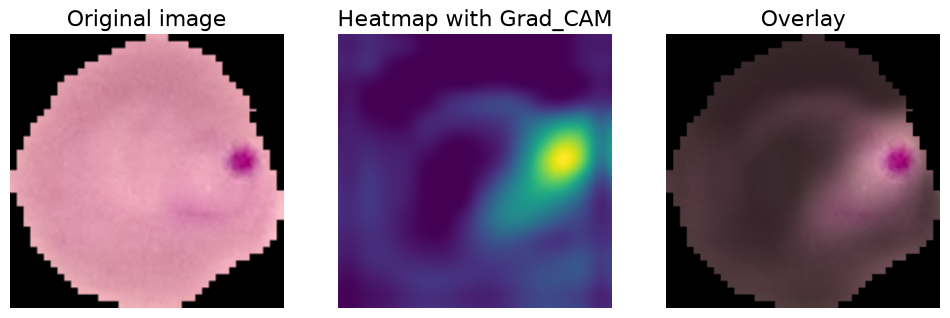

In [60]:
from skimage.exposure import rescale_intensity
from skimage.transform import resize

rescaled_image=rescale_intensity(np.array(image_hr), out_range=(0,1))
resized_heatmap = resize(heatmap, rescaled_image.shape[:2], order=2)
rescaled_heatmap = rescale_intensity(resized_heatmap, out_range=(0.25, 1))

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
ax=np.ravel(ax)
ax[0].imshow(rescaled_image, interpolation="bilinear")
ax[0].set_title ("Original image", fontsize=16)
ax[0].axis("off")

im=ax[1].imshow(rescaled_heatmap, interpolation="bilinear")
ax[1].set_title("Heatmap with Grad_CAM", fontsize=16)
ax[1].axis("off")
# plt.colorbar(im, orientation="horizontal")

ax[2].imshow(rescaled_image * rescaled_heatmap[..., None])   # broadcast over RGB channels
ax[2].set_title("Overlay", fontsize=16)
ax[2].axis("off")

plt.show()